<a href="https://colab.research.google.com/github/alex-olar-2/tehinva-project/blob/main/olar_alex_tema_b_income_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Acest Notebook a fost preluat de la Stefan-Gheorghe PENTIUC precizați sursa, autorul, link-
ul https://classroom.google.com/c/ODQ1ODIxOTcyMzQ4 astfel:

- secventele de cod 50 %
- comentariile 0 %

Acest Notebook a fost generat cu CLAUDE si GEMINI precizați sursa, autorul, link-
ul https://claude.ai/, https://gemini.google.com/app astfel:

- secventele de cod 20 %
- comentariile 0 %

Conributia personala a constat în:
- adaptarea codului
- studierea documentelor
- comentarii

Valorile procentuale de mai sunt aproximative dar reflectă în esență adevărul.

# 1.   Descrierea problemei




## 1.1. Partea teoretica

Identificarea unui patern a persoanelor care castiga un venit de peste sau sub 50k avand primordial parametrii varstei, educatiei si ore lucrate pe saptamana.

## 1.2. Partea practica

Validarea informatiilor fisierului income_evaluation.csv [1] prin 2 metode de invatare:

1.   Regresie si/sau
2.   Clasificare

Vizualizarea datelor in mai multe posibilitati folosind biblioteci si cod .py.

# 2. Procesarea datelor

In [50]:
import kagglehub
import pandas as pd
import numpy as np
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

file_path = 'income_evaluation.csv'

column_names = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education-num',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'native-country',
    'income'
]

target_names = ['<=50K', '>50K']

data_frame = pd.read_csv(file_path, sep=',', names=column_names, header=0)

data_frame_without_income = data_frame.drop(columns='income')

matrix_data_frame_without_income = data_frame_without_income.to_numpy()

income_feature = data_frame['income'].str.strip().map({'<=50K': 1, '>50K': 2})

income_feature_vector = income_feature.to_numpy()

row_number, column_number = matrix_data_frame_without_income.shape

max_income_feature_vector =  max(income_feature_vector)

print("Primele 3 randuri din matricea datelor: \n", matrix_data_frame_without_income[:3])

print("Primele 2 valori din vectorul coloanei income: \n", income_feature_vector[:2])

print("Nr. de linii si de coloane al matricei: \n", matrix_data_frame_without_income.shape)

print("Nr. valori a vectorului de income: \n", income_feature_vector.shape)

print("Valoarea cea mai des intalnita in vecotrul de income: \n", max_income_feature_vector)

Primele 3 randuri din matricea datelor: 
 [[39 ' State-gov' 77516 ' Bachelors' 13 ' Never-married' ' Adm-clerical'
  ' Not-in-family' ' White' ' Male' 2174 0 40 ' United-States']
 [50 ' Self-emp-not-inc' 83311 ' Bachelors' 13 ' Married-civ-spouse'
  ' Exec-managerial' ' Husband' ' White' ' Male' 0 0 13 ' United-States']
 [38 ' Private' 215646 ' HS-grad' 9 ' Divorced' ' Handlers-cleaners'
  ' Not-in-family' ' White' ' Male' 0 0 40 ' United-States']]
Primele 2 valori din vectorul coloanei income: 
 [1 1]
Nr. de linii si de coloane al matricei: 
 (32561, 14)
Nr. valori a vectorului de income: 
 (32561,)
Valoarea cea mai des intalnita in vecotrul de income: 
 2


Sursa: lab_seeds_v3.ipynb [2]

Debug: Gemini [3]

## 2.1. Vizualizarea datelor 3D

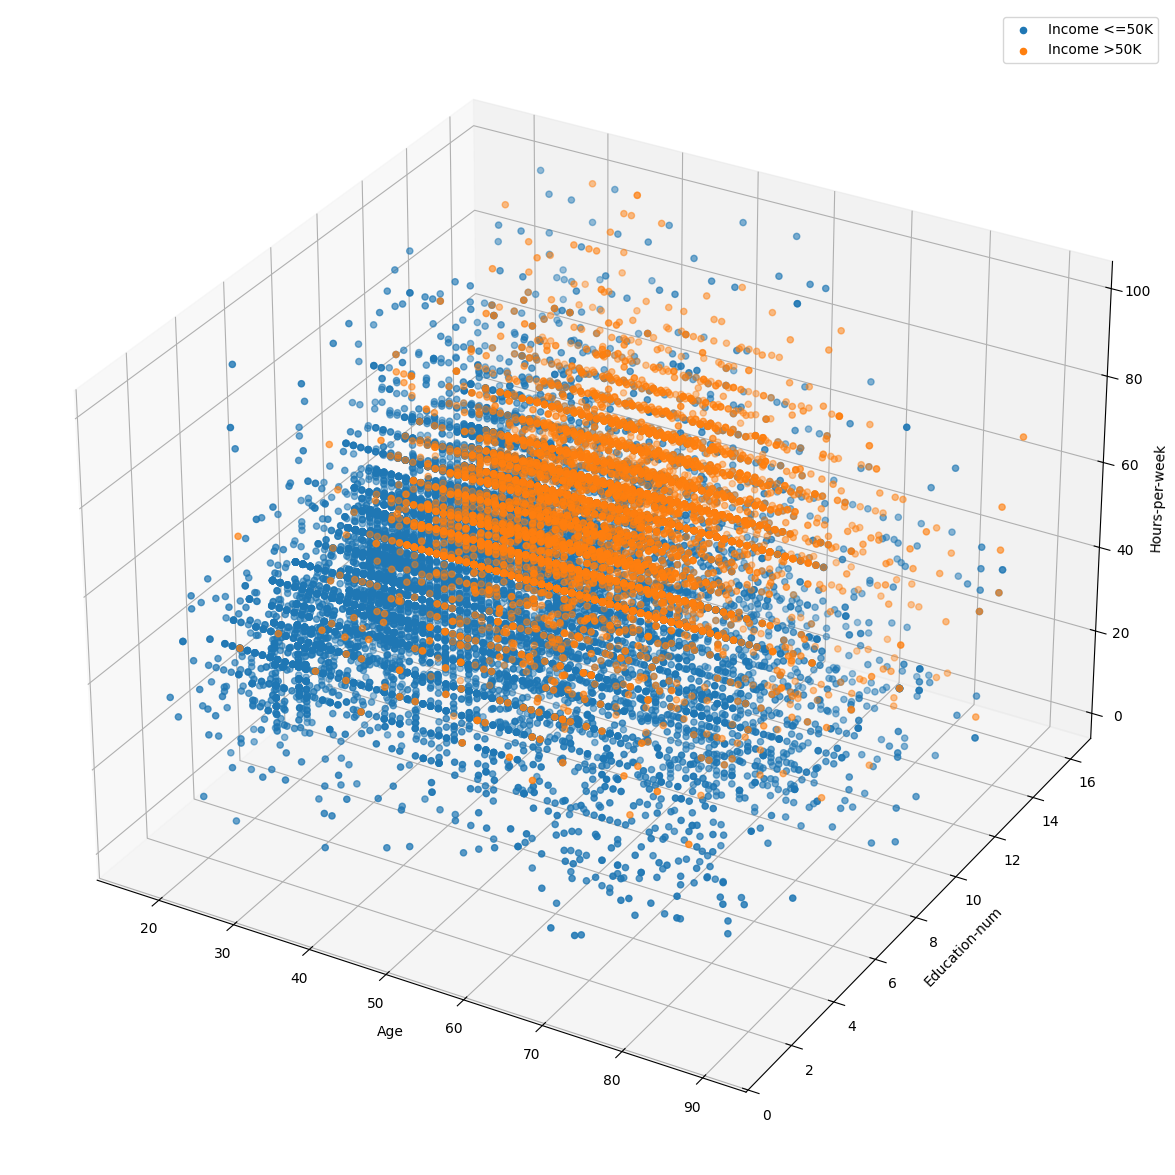

In [51]:
import matplotlib.pyplot as plt

colours = ('r', 'g', 'b', 'c', 'm', 'y', 'k', 'w', 'orange', 'purple')

fig = plt.figure(figsize=(15, 15))

add_subplot = fig.add_subplot(111, projection='3d')

for iclass in range(1, min(max_income_feature_vector + 1, len(colours))):
    add_subplot.scatter(
        matrix_data_frame_without_income[income_feature_vector == iclass, 0].astype(float),
        matrix_data_frame_without_income[income_feature_vector == iclass, 4].astype(float),
        matrix_data_frame_without_income[income_feature_vector == iclass, 12].astype(float),
        label=f'Income {"<=50K" if iclass == 1 else ">50K"}'
    )

add_subplot.set_xlabel('Age')
add_subplot.set_ylabel('Education-num')
add_subplot.set_zlabel('Hours-per-week')
add_subplot.legend()

plt.show()

Sursa: lab_seeds_v3.ipynb [2]

Debug: Gemini [3]

## 2.2. Vizualizarea datelor 2D

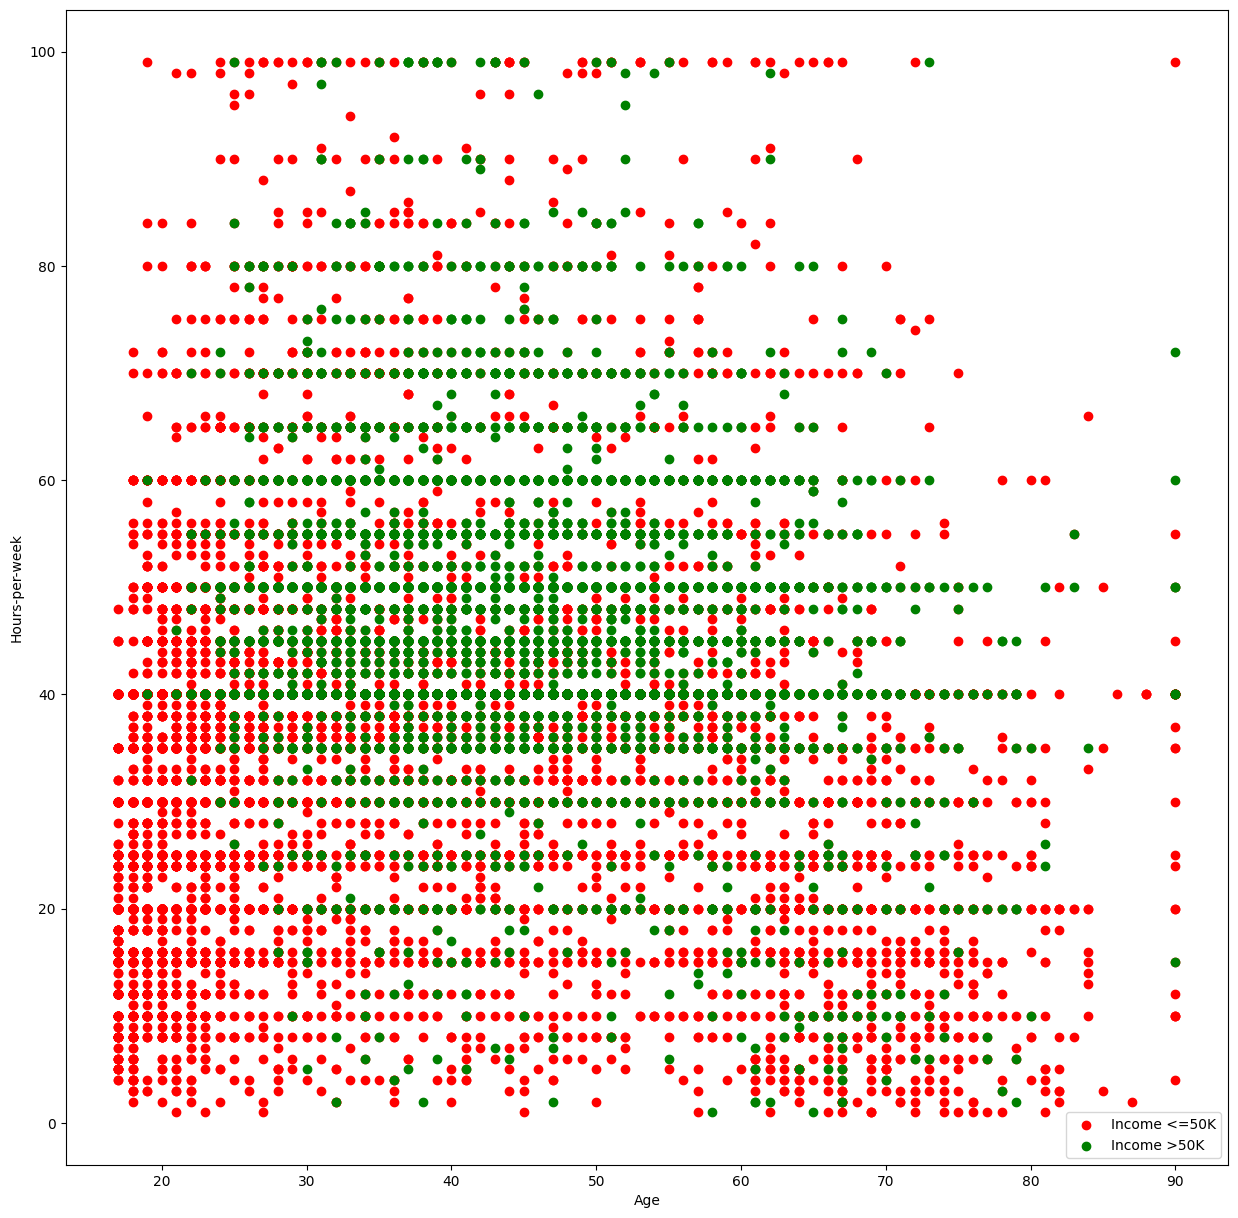

In [52]:
plt.figure(figsize=(15, 15))

for iclass in range(1, min(max_income_feature_vector + 1, len(colours))):
    plt.scatter(
        matrix_data_frame_without_income[income_feature_vector == iclass, 0].astype(float),
        matrix_data_frame_without_income[income_feature_vector == iclass, 12].astype(float),
        c=colours[iclass-1],
        label=f'Income {"<=50K" if iclass == 1 else ">50K"}'
    )

plt.xlabel('Age')
plt.ylabel('Hours-per-week')
plt.legend()

plt.show()

Sursa: lab_seeds_v3.ipynb [2]

Debug: Gemini [3]

## 2.3 Vizualizare TSNE

Nr. de linii si coloane a matricii in 2d: 
 (100, 2)


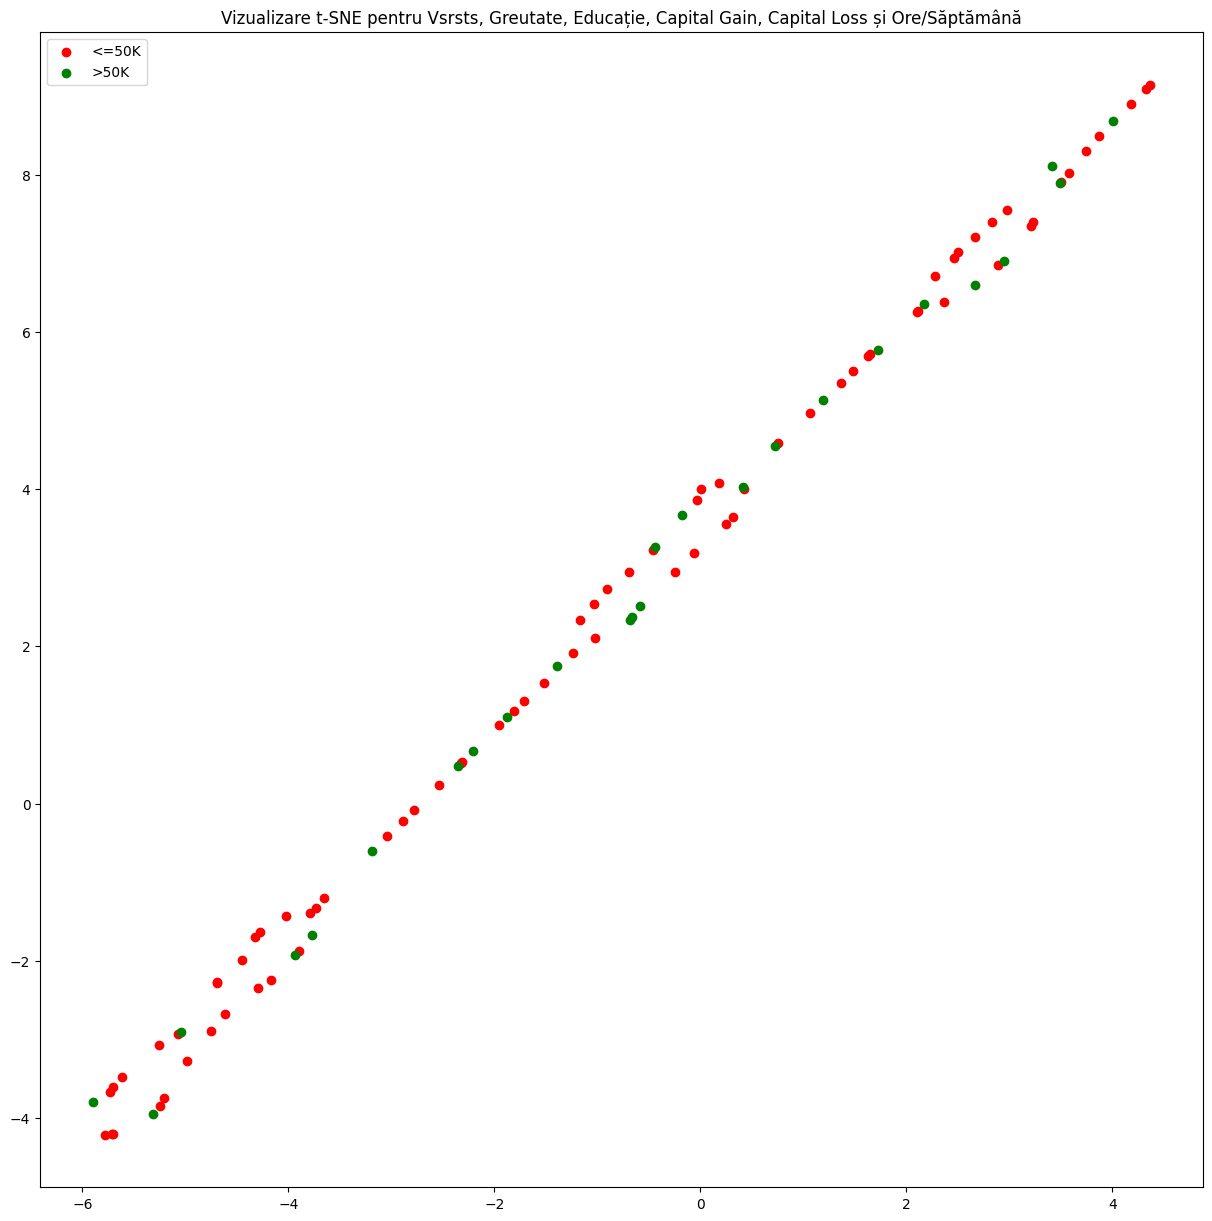

In [53]:
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt

def afisTSNE(matrix_data_frame_without_income, income_feature_vector, n_components = 2):
    tsne = TSNE(n_components, random_state = 0)

    indici_numerici = [0, 2, 4, 10, 11, 12]

    matrix_data_frame_without_income_2d = tsne.fit_transform(
        matrix_data_frame_without_income[:, indici_numerici].astype(float)
    )
    print("Nr. de linii si coloane a matricii in 2d: \n", matrix_data_frame_without_income_2d.shape)

    target_ids = range(1, len(target_names) + 1)

    fig = plt.figure(figsize=(15, 15))
    if n_components == 3:
        ax = fig.add_subplot(111, projection='3d')

    colors = 'r', 'g', 'b', 'c', 'm', 'y', 'k', 'w', 'orange', 'purple'

    for i, c, label in zip(target_ids, colors, target_names):
        if n_components==2:
            plt.scatter(
                matrix_data_frame_without_income_2d[income_feature_vector == i, 0].astype(float),
                matrix_data_frame_without_income_2d[income_feature_vector == i, 1].astype(float),
                c=c,
                label=label
            )
        else:
            ax.scatter(
                matrix_data_frame_without_income_2d[income_feature_vector == i, 0].astype(float),
                matrix_data_frame_without_income_2d[income_feature_vector == i, 1].astype(float),
                matrix_data_frame_without_income_2d[income_feature_vector == i, 2].astype(float),
                c=c,
                label=label
            )

    plt.legend()
    plt.title("Vizualizare t-SNE pentru Vsrsts, Greutate, Educație, Capital Gain, Capital Loss și Ore/Săptămână")
    plt.show()

afisTSNE(matrix_data_frame_without_income[:100], income_feature_vector[:100])

Sursa cod initial: lab_seeds_v3.ipynb [2]

Debug: Gemini [3]

# 3. Analiza Explorativa a Datelor

## 3.1 Min, Media, Max

In [54]:
print('\nMin, Media, ..., Max\n')
display(data_frame.describe())


Min, Media, ..., Max



,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Sursa cod initial: lab_seeds_v3.ipynb [2]

## 3.2. Coeficientii de corelatie

In [55]:

print('\nCoeficientii de corelatie\n')
display(data_frame.corr(numeric_only=True))


Coeficientii de corelatie



,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education-num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital-gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital-loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours-per-week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


Sursa cod initial: lab_seeds_v3.ipynb [2]

## 3.3. Diagrama de tip pairplot


Diagrama de tip pairplot a primelor 1000 de valori:



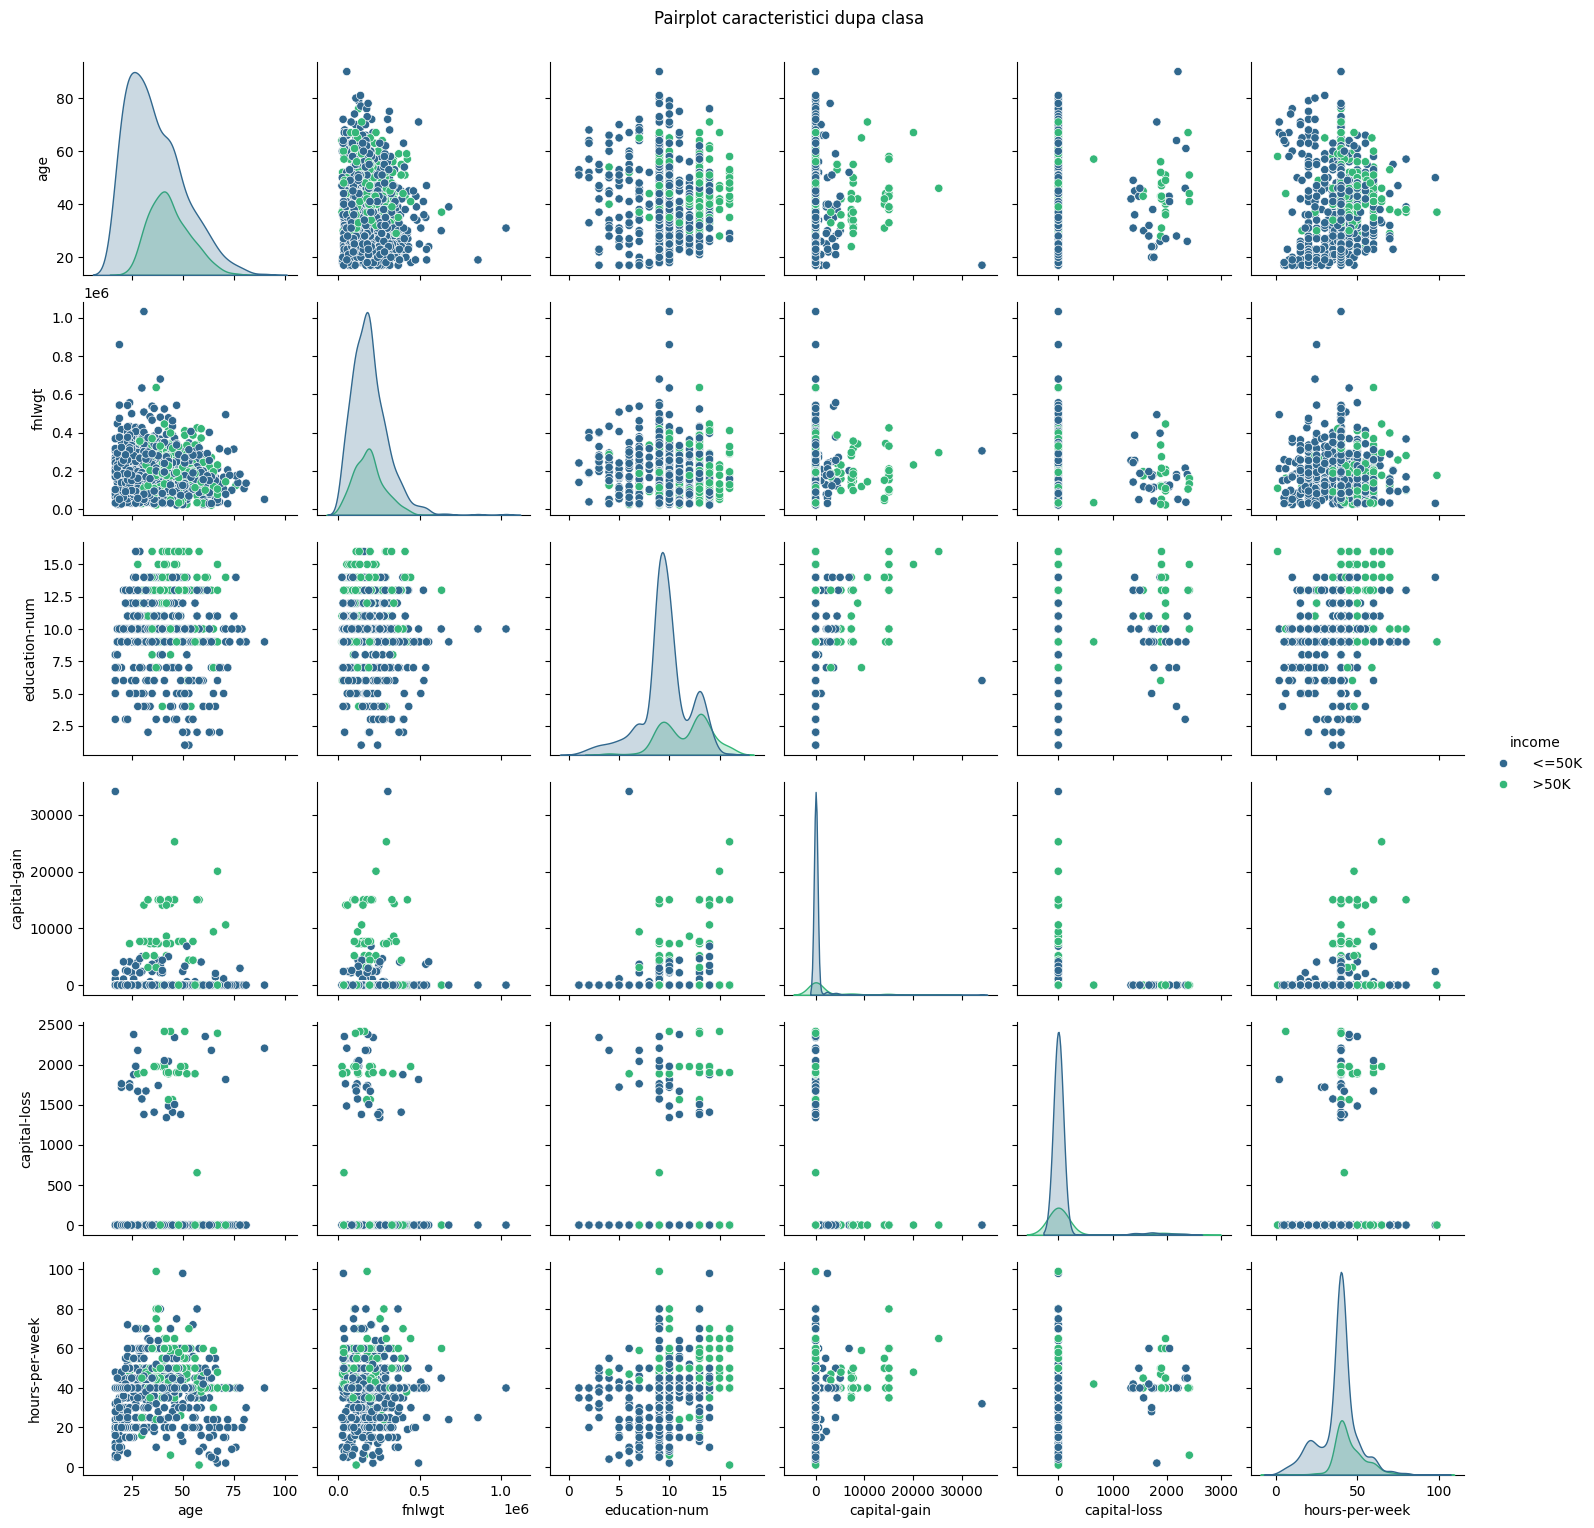

In [56]:
print('\nDiagrama de tip pairplot a primelor 1000 de valori:\n')
sns.pairplot(data_frame[:1000], hue='income', palette='viridis')
plt.suptitle('Pairplot caracteristici dupa clasa', y=1.02)
plt.show()

Sursa cod initial: lab_seeds_v3.ipynb [2]

# 4. Modelare de invatare automata

## 4.1. Invatare supravegheata

In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn import svm

clasificatori = [ KNeighborsClassifier(n_neighbors=k) for k in [3, 5, 7, 9] ]
clasificatori += [ GaussianNB(),
                  svm.LinearSVC(),
                   svm.SVC(),
                   GaussianProcessClassifier(1.0 * RBF(1.0))
                 ]

Sursa cod initial: lab_seeds_v3.ipynb [2]

## 4.2. Regresie si/sau

## 4.3. Clasificare

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, QuantileTransformer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn import svm
import pandas as pd

indici_numerici = [0, 2, 4, 10, 11, 12]

preprocessors = {
    'fara': None,
    'std': StandardScaler(),
    'minmax': MinMaxScaler(),
    'robust': RobustScaler(),
    'quantile_uniform': QuantileTransformer(output_distribution='uniform', random_state=42),
    'quantile_normal': QuantileTransformer(output_distribution='normal', random_state=42),
    'select_kbest_chi2': SelectKBest(chi2)
}

preprocessor_params = {
    'quantile_uniform': {'pre__n_quantiles': [10, 50, 100]},
    'quantile_normal': {'pre__n_quantiles': [10, 50, 100]},
    'select_kbest_chi2': {'pre__k': [2, 3, 4, 5, 6, 7]}
}

classifier_params = {
    KNeighborsClassifier: {
        'clf__n_neighbors': [1, 3, 5, 7, 9],
        'clf__weights': ['uniform', 'distance']
    },
    GaussianNB: {},
    svm.LinearSVC: {
        'clf__C': [0.1, 1, 10],
        'clf__max_iter': [1000, 2000]
    },
    # svm.SVC: {
    #     'clf__C': [0.1, 1, 10],
    #     'clf__kernel': ['linear', 'rbf', 'poly'],
    #     'clf__gamma': ['scale', 'auto']
    # }
}

best_overall_score = -1
best_overall_params = {}
best_overall_clf_name = ""
best_overall_pre_name = ""

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


for clf in clasificatori:
    clf_name = type(clf).__name__
    print(f"\nClasificator = {clf_name}")

    for pre_name, preprocessor in preprocessors.items():
        pipeline_steps = []
        param_grid_for_combo = {}

        if preprocessor is not None:
            pipeline_steps.append(('pre', preprocessor))
            if pre_name in preprocessor_params:
                param_grid_for_combo.update(preprocessor_params[pre_name])

        pipeline_steps.append(('clf', clf))
        pipeline = Pipeline(pipeline_steps)

        for clf_class, params in classifier_params.items():
            if isinstance(clf, clf_class):
                param_grid_for_combo.update(params)
                break

        current_mean_accuracy = 0
        current_best_params = {}

        if not param_grid_for_combo:
            scores = cross_val_score(pipeline,
                                     matrix_data_frame_without_income[:100, indici_numerici].astype(float),
                                     income_feature_vector[:100],
                                     cv=cv_strategy,
                                     scoring='accuracy',
                                     n_jobs=-1
                                    )
            current_mean_accuracy = scores.mean()
            current_best_params = {}
        else:
            grid_search = GridSearchCV(pipeline,
                                       param_grid_for_combo,
                                       cv=cv_strategy,
                                       scoring='accuracy',
                                       n_jobs=-1,
                                       verbose=0
                                      )

            grid_search.fit(matrix_data_frame_without_income[:100, indici_numerici].astype(float),
                            income_feature_vector[:100]
                           )

            current_mean_accuracy = grid_search.best_score_
            current_best_params = grid_search.best_params_

        print(f"\t Preprocesor = {pre_name} : {current_best_params} Acc. medie: {current_mean_accuracy:.4f}")

        if current_mean_accuracy > best_overall_score:
            best_overall_score = current_mean_accuracy
            best_overall_params = current_best_params
            best_overall_clf_name = clf_name
            best_overall_pre_name = pre_name

print(f"\nCea mai buna combinatie: {best_overall_pre_name} + {best_overall_clf_name}: {best_overall_params}, Score mediu CV: {best_overall_score:.4f}")


Clasificator = KNeighborsClassifier
	 Preprocesor = fara : {'clf__n_neighbors': 9, 'clf__weights': 'uniform'} Acc. medie: 0.7500
	 Preprocesor = std : {'clf__n_neighbors': 7, 'clf__weights': 'distance'} Acc. medie: 0.7800
	 Preprocesor = minmax : {'clf__n_neighbors': 7, 'clf__weights': 'uniform'} Acc. medie: 0.7600
	 Preprocesor = robust : {'clf__n_neighbors': 7, 'clf__weights': 'uniform'} Acc. medie: 0.7800
	 Preprocesor = quantile_uniform : {'clf__n_neighbors': 9, 'clf__weights': 'uniform', 'pre__n_quantiles': 10} Acc. medie: 0.8000
	 Preprocesor = quantile_normal : {'clf__n_neighbors': 9, 'clf__weights': 'uniform', 'pre__n_quantiles': 50} Acc. medie: 0.7700
	 Preprocesor = select_kbest_chi2 : {'clf__n_neighbors': 9, 'clf__weights': 'uniform', 'pre__k': 4} Acc. medie: 0.7600

Clasificator = KNeighborsClassifier
	 Preprocesor = fara : {'clf__n_neighbors': 9, 'clf__weights': 'uniform'} Acc. medie: 0.7500
	 Preprocesor = std : {'clf__n_neighbors': 7, 'clf__weights': 'distance'} Acc. me

Sursa cod initial: lab_seeds_v3.ipynb [2]

## 4.4. Analiza performantelor clasificatorilor

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

indici_numerici = [0, 2, 4, 10, 11, 12]

clf = DecisionTreeClassifier()
clf.fit(matrix_data_frame_without_income[:, indici_numerici], income_feature_vector)

income_feature_vector_predicted = clf.predict(matrix_data_frame_without_income[:, indici_numerici])

print(f"\nAccuracy {clf.score(matrix_data_frame_without_income[:, indici_numerici],income_feature_vector)}\n")
print(f"\nClasificari eronate(%): { np.count_nonzero(income_feature_vector_predicted != income_feature_vector)/income_feature_vector.shape[0]}\n")

print("\nMatricea de cunfuzie: \n", confusion_matrix(income_feature_vector_predicted, income_feature_vector))
print("\nRaport de clasificare\n", classification_report(income_feature_vector_predicted, income_feature_vector))


Accuracy 0.9987715365007217


Clasificari eronate(%): 0.0012284634992782777


Matricea de cunfuzie: 
 [[24720    40]
 [    0  7801]]

Raport de clasificare
               precision    recall  f1-score   support

           1       1.00      1.00      1.00     24760
           2       0.99      1.00      1.00      7801

    accuracy                           1.00     32561
   macro avg       1.00      1.00      1.00     32561
weighted avg       1.00      1.00      1.00     32561



Sursa cod initial: lab_seeds_v3.ipynb [2]

## 4.5. Matricea de confuzie


Matricea de confuzie: 
 [[4187  839]
 [ 675  812]]

Raport de clasificare: 
               precision    recall  f1-score   support

           1       0.86      0.83      0.85      5026
           2       0.49      0.55      0.52      1487

    accuracy                           0.77      6513
   macro avg       0.68      0.69      0.68      6513
weighted avg       0.78      0.77      0.77      6513


Matricea de confuzie vizual: 



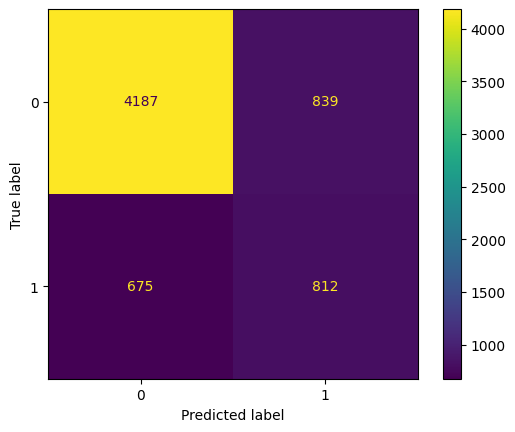

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

indici_numerici = [0, 2, 4, 10, 11, 12]

matrix_data_frame_without_income_train, matrix_data_frame_without_income_test, income_feature_vector_train, income_feature_vector_test = train_test_split(matrix_data_frame_without_income[:, indici_numerici], income_feature_vector, test_size=0.20, random_state=1)

clasificator = DecisionTreeClassifier()
clasificator.fit(
    matrix_data_frame_without_income_train,
    income_feature_vector_train
)

income_feature_vector_predict_test = clasificator.predict(matrix_data_frame_without_income_test)

mat_conf = confusion_matrix(
    income_feature_vector_test,
    income_feature_vector_predict_test
)

print("\nMatricea de confuzie: \n", mat_conf)
print("\nRaport de clasificare: \n", classification_report(
    income_feature_vector_test,
    income_feature_vector_predict_test)
)
print("\nMatricea de confuzie vizual: \n")
cm_display = ConfusionMatrixDisplay(mat_conf).plot()

Sursa cod initial: lab_seeds_v3.ipynb [2]

# 5. Compararea si validarea modelelor

Din rezultatele furnizate la punctul 4.5. cea mai buna configuratie posibila pentru clasifica informatiile date este robust + LinearSVC, rezultatul fiind de 85%.

Putem valida atat cea mai buna configuratie cat si celelalte prin prisma faptului ca au avut un minim de 73% acuratete in determinarea venitului prin cei 6 parametrii: varsta, greutate, educatie, capital gain, capital loss, ore lucrate pe saptamana.

# 6. Implementarea

In [ ]:
import sys
import os
import argparse
import time

import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

COLUMN_NAMES = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

INDICI_NUMERICI = [0, 2, 4, 10, 11, 12]

FEATURE_NAMES = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

NUM_FEATURES = len(FEATURE_NAMES)

TARGET_NAMES = {1: '<=50K', 2: '>50K'}

DEFAULT_DATASET = 'income_evaluation.csv'
DEFAULT_INPUT   = 'observatii_input.csv'


def separator(char='═', width=62):
    print(char * width)

def titlu(text, char='═'):
    separator(char)
    print(f"  {text}")
    separator(char)

def subsectiune(text):
    print(f"\n{'─'*62}")
    print(f"  {text}")
    print(f"{'─'*62}")


def incarca_dataset(cale_fisier: str) -> pd.DataFrame:
    if not os.path.isfile(cale_fisier):
        raise FileNotFoundError(
            f"Fisierul dataset '{cale_fisier}' nu a fost gasit.\n"
            f"Descarcati-l de la: https://www.kaggle.com/datasets/lodetomasi1995/income-classification\n"
            f"sau rulati: python -c \"import kagglehub; kagglehub.dataset_download('lodetomasi1995/income-classification')\""
        )

    df = pd.read_csv(cale_fisier, sep=',', names=COLUMN_NAMES, header=0)

    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.strip()

    df.replace('?', np.nan, inplace=True)
    df.dropna(inplace=True)

    return df

def pregatire_si_antrenare(df: pd.DataFrame):
    X_all = df.drop(columns='income').to_numpy()

    y_all = df['income'].map({'<=50K': 1, '>50K': 2}).to_numpy()

    X = X_all[:, INDICI_NUMERICI].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_all, test_size=0.20, random_state=42, stratify=y_all
    )

    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    scor   = accuracy_score(y_test, y_pred)

    return model, scor, X_test, y_test, y_pred

def citeste_observatii_din_fisier(cale_fisier: str) -> np.ndarray:
    if not os.path.isfile(cale_fisier):
        raise FileNotFoundError(
            f"Fisierul de intrare '{cale_fisier}' nu a fost gasit.\n"
            f"Creati un fisier CSV cu coloanele:\n"
            f"  {', '.join(FEATURE_NAMES)}"
        )

    df_input = pd.read_csv(cale_fisier, comment='#')

    if set(FEATURE_NAMES).issubset(set(df_input.columns)):
        X_input = df_input[FEATURE_NAMES].to_numpy(dtype=float)
    elif df_input.shape[1] == NUM_FEATURES:
        X_input = df_input.to_numpy(dtype=float)
    else:
        raise ValueError(
            f"Fisierul '{cale_fisier}' trebuie sa aiba exact {NUM_FEATURES} coloane:\n"
            f"  {', '.join(FEATURE_NAMES)}"
        )

    return X_input, df_input

def interpreteaza_probabilitate(prob_vec):
    prob_max = max(prob_vec)
    if prob_max >= 0.90:
        return "●●●●● (Incredere foarte inalta)"
    elif prob_max >= 0.75:
        return "●●●●○ (Incredere inalta)"
    elif prob_max >= 0.60:
        return "●●●○○ (Incredere medie)"
    else:
        return "●●○○○ (Incredere scazuta)"


def afiseaza_predictii(model, X_input, df_input):
    subsectiune("REZULTATE PREDICTII")

    predictii      = model.predict(X_input)
    probabilitati  = model.predict_proba(X_input)

    print(f"\n  {'Nr':>3}  {'Varsta':>6}  {'Edu-Num':>7}  {'Ore/Sapt':>8}  {'Cap.Gain':>8}  "
          f"{'Cap.Loss':>8}  {'Predictie':>9}  {'Prob %':>6}")
    print(f"  {'─'*3}  {'─'*6}  {'─'*7}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*9}  {'─'*6}")

    for i in range(len(X_input)):
        rand  = X_input[i]
        pred  = predictii[i]
        prob  = probabilitati[i]

        eticheta = TARGET_NAMES[pred]
        semn     = "↑" if pred == 2 else "↓"

        print(
            f"  {i+1:>3}.  "
            f"{int(rand[0]):>6}  "
            f"{int(rand[2]):>7}  "
            f"{int(rand[5]):>8}  "
            f"{int(rand[3]):>8}  "
            f"{int(rand[4]):>8}  "
            f"  {semn} {eticheta:<7}  "
            f"{max(prob)*100:>5.1f}%"
        )

    subsectiune("DETALIU COMPLET PER OBSERVATIE")
    for i in range(len(X_input)):
        rand = X_input[i]
        pred = predictii[i]
        prob = probabilitati[i]

        print(f"\n  ┌─ Observatia #{i+1} {'─'*40}")
        print(f"  │  Varsta              : {int(rand[0])} ani")
        print(f"  │  Greutate (fnlwgt)   : {int(rand[1])}")
        print(f"  │  Nivel educatie (num): {int(rand[2])}")
        print(f"  │  Capital Gain        : {int(rand[3])}")
        print(f"  │  Capital Loss        : {int(rand[4])}")
        print(f"  │  Ore lucrate/sapt.   : {int(rand[5])}")
        print(f"  ├{'─'*50}")
        print(f"  │  ► PREDICTIE VENIT  : {TARGET_NAMES[pred]}")
        print(f"  │  Prob. <=50K         : {prob[0]*100:.1f}%")
        print(f"  │  Prob. >50K          : {prob[1]*100:.1f}%")
        print(f"  │  Incredere           : {interpreteaza_probabilitate(prob)}")
        print(f"  └{'─'*50}")

    subsectiune("SUMAR")
    n_total    = len(predictii)
    n_sub_50k  = int(np.sum(predictii == 1))
    n_peste_50k = int(np.sum(predictii == 2))
    print(f"  Total observatii analizate : {n_total}")
    print(f"  Persoane cu venit <=50K    : {n_sub_50k}  ({n_sub_50k/n_total*100:.1f}%)")
    print(f"  Persoane cu venit  >50K    : {n_peste_50k}  ({n_peste_50k/n_total*100:.1f}%)")

def afiseaza_performanta_model(scor, X_test, y_test, y_pred):
    """Afiseaza metricile de performanta ale modelului antrenat."""
    subsectiune("PERFORMANTA MODEL (set de test 20%)")
    print(f"  Accuracy : {scor*100:.2f}%")
    print(f"\n  Raport de clasificare:\n")
    raport = classification_report(
        y_test, y_pred,
        target_names=['<=50K', '>50K'],
        zero_division=0
    )
    for linie in raport.split('\n'):
        print(f"    {linie}")

def main():
    parser = argparse.ArgumentParser(
        description='Aplicatie demo predictie venit (<=50K / >50K)'
    )
    parser.add_argument(
        '--input',   default=DEFAULT_INPUT,
        help=f'Fisier CSV cu observatii de prezis (implicit: {DEFAULT_INPUT})'
    )
    parser.add_argument(
        '--dataset', default=DEFAULT_DATASET,
        help=f'Fisier CSV dataset antrenament (implicit: {DEFAULT_DATASET})'
    )
    args = parser.parse_args()

    titlu("APLICATIE DEMO – PREDICTIA VENITULUI")
    print(f"  Dataset antrenament : {args.dataset}")
    print(f"  Fisier observatii   : {args.input}")
    print(f"  Nr. caracteristici  : {NUM_FEATURES}  (> 5 → citire din FISIER)")
    print(f"  Caracteristici      : {', '.join(FEATURE_NAMES)}")
    print(f"  Model               : DecisionTreeClassifier")
    separator('─')

    subsectiune("PASUL 1 – Incarcare dataset de antrenament")
    print(f"  Se incarca: '{args.dataset}' ...", end=' ', flush=True)
    try:
        df = incarca_dataset(args.dataset)
        print(f"OK  ({len(df):,} observatii, {df.shape[1]} coloane)")
    except FileNotFoundError as e:
        print(f"EROARE!\n\n{e}\n")
        sys.exit(1)

    subsectiune("PASUL 2 – Antrenare model DecisionTreeClassifier")
    print("  Se antreneaza modelul ...", end=' ', flush=True)
    t0 = time.time()
    model, scor, X_test, y_test, y_pred = pregatire_si_antrenare(df)
    durata = time.time() - t0
    print(f"OK  ({durata:.2f}s)")
    print(f"  Accuracy pe setul de test : {scor*100:.2f}%")

    afiseaza_performanta_model(scor, X_test, y_test, y_pred)

    subsectiune(f"PASUL 3 – Citire observatii din fisier '{args.input}'")
    print(f"  (Nr. caracteristici = {NUM_FEATURES} > 5  →  citire din FISIER)")
    try:
        X_input, df_input = citeste_observatii_din_fisier(args.input)
        print(f"  Observatii citite cu succes : {len(X_input)}")
    except (FileNotFoundError, ValueError) as e:
        print(f"  EROARE: {e}")
        sys.exit(1)

    subsectiune("PASUL 4 – Realizare predictii")
    afiseaza_predictii(model, X_input, df_input)

    separator()
    print("  Aplicatie finalizata cu succes.")
    separator()


if __name__ == '__main__':
    main()


Sursa cod generat 100%: Claude AI [4]

# 7. Concluzii

O concluzie a acestui material o reprezinta cunostintele noi dobandite in realizarea acestui material.

Una dintre ele o constituie cerinta de a lucra in Google Research Colab [5]. Cat si obligativitatea morala de a crea un document in care sursele sunt 100% expuse in procentaje care exprima realitatea.

O alta cunostinta dobandita este modul in care am reusit sa gestionam un cod in limbajul de programare Python [6], pentru generarea unui algoritm care ne poate prezice in dependinta a 6 parametrii (ani, greutate, educatie, capital gain, capital loss, ore pe saptamana lucrate), in documentul de fata, daca o persoana poate avea un venit de 50k sau nu. Cat si folosirea cat mai putina a unui IAG (Inteligenta Artificiala Generativa) [7], pentru a promova originalitatea si creativitatea.

# 8. Referinte

[1]
Lorenzo De Tomasi, "Income classification", https://www.kaggle.com/datasets/lodetomasi1995/income-classification/code

[3] Google, "Gemini", https://gemini.google.com/app

[4] Antropic, "Claude", https://claude.ai/new

[5] Google, "Colab", https://colab.research.google.com/

[6] Python Software Foundation, "Python", https://www.python.org/

[7] Wikipedia, Inteligenta Artificiala Generativa, https://ro.wikipedia.org/wiki/Inteligen%C8%9Ba_artificial%C4%83_generativ%C4%83

# 9. Anexe

[2] Stefan-Gheorghe PENTIUC, "Lucrarea de laborator nr. 5", https://drive.google.com/file/d/1wH6EDkZWXNpJukRhQFxcvK2j1NdG7e4k/view